# Monitoring a Deployed Model and Knowing When to Retrain

A model that was accurate last month may be inaccurate today. The real world changes — new user behaviour, seasonal patterns, data pipeline bugs — and models degrade silently unless you monitor them. This notebook builds a simple monitoring pipeline: log predictions, detect distribution shift, and decide when to trigger a retraining job.

**Learning objectives**
1. Explain the difference between data drift and concept drift.
2. Build a request logger that writes predictions to a JSON-lines file.
3. Simulate a distribution shift and visualize how model confidence drops.
4. Implement a simple statistical drift detector using mean/std thresholds.
5. Define a retraining trigger rule based on drift detection or accuracy degradation.

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 09 "09. Model Monitoring and Performance Tracking" — you met data drift and concept drift as concepts there; here the detector is wired to an explicit retraining trigger, so the monitoring output finally becomes a decision.


## 📰 Zillow shut down a business because its model could not keep up

Zillow Offers bought homes directly from sellers at a price its model estimated, then resold them. On **2 November 2021** Zillow announced it was winding the business down. In the same quarter it recorded a **$304.4 million write-down** on inventory — homes it had bought at prices above what it now expected to sell them for — and told investors to expect a further **$240–265 million** in the following quarter. The wind-down involved cutting about **25% of the company's workforce**. Zillow's own explanation was not that the model was badly built: *"we've determined the unpredictability in forecasting home prices far exceeds what we anticipated."*

That is what concept drift costs when nobody is watching for it. The model kept producing confident numbers. The housing market underneath it stopped behaving the way the training data said it would.

**What goes wrong without this lesson.** A deployed model has no idea that the world has moved. It cannot fail loudly, because from its point of view nothing has changed — it is given a row of numbers and it returns a prediction, exactly as it always has. Without logging, without a baseline to compare against, and without a rule that fires, degradation is invisible until it shows up somewhere expensive: in a write-down, in a complaint, or in a regulator's letter.

## 1  Why monitoring matters

Two types of drift cause silent model degradation:

- **Data drift**: the distribution of input features changes. Example: a product recommendation model trained on desktop users starts receiving mostly mobile traffic.
- **Concept drift**: the relationship between features and labels changes. Example: a fraud model trained before a new type of fraud becomes common.

Without logs, you cannot detect either. You need to record inputs and predictions for every request.


In [1]:
# WHAT: train the model AND record the training data's mean/std per feature.
# WHY: monitoring needs a baseline — drift is always measured as 'how far is live
# traffic from what the model saw in training', so we freeze that reference now.
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import json
import time
import os
from datetime import datetime, timedelta

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# The deployed artifact: scaler + forest, same pattern as earlier lessons.
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])
model.fit(X_train, y_train)

# Compute training distribution baseline
TRAIN_MEAN = X_train.mean(axis=0)
TRAIN_STD = X_train.std(axis=0)
CLASS_NAMES = list(iris.target_names)

print(f"Model accuracy on test set: {model.score(X_test, y_test):.2%}")
print(f"Training distribution mean (per feature): {TRAIN_MEAN.round(3)}")
print(f"Training distribution std  (per feature): {TRAIN_STD.round(3)}")

Model accuracy on test set: 100.00%
Training distribution mean (per feature): [5.809 3.062 3.727 1.183]
Training distribution std  (per feature): [0.82  0.447 1.745 0.749]


## 2  Request logger

Every prediction gets logged with its timestamp, raw features, prediction, and confidence. We write to a JSON-lines file (one JSON object per line) — simple, append-friendly, and parseable.


In [2]:
# WHAT: define logging helpers — every prediction is appended to a JSON-lines file.
# WHY: you cannot monitor what you never recorded; the log (inputs, prediction,
# confidence, timestamp) is the raw material for every check that follows.
LOG_PATH = "/tmp/prediction_log.jsonl"

# Clear any previous log
if os.path.exists(LOG_PATH):
    os.remove(LOG_PATH)

# One line of JSON per request: append-only, cheap, and easy to replay later.
def log_prediction(features, prediction, confidence, timestamp=None):
    """Append one prediction record to the JSON-lines log."""
    record = {
        "timestamp": (timestamp or datetime.utcnow()).isoformat(),
        "features": list(float(v) for v in features),
        "prediction": prediction,
        "confidence": round(float(confidence), 4)
    }
    with open(LOG_PATH, "a") as f:
        f.write(json.dumps(record) + "\n")
    return record


# Wrap predict() so serving and logging always happen together.
def predict_and_log(model, features, timestamp=None):
    """Run prediction and log it. Returns the log record."""
    arr = np.array(features).reshape(1, -1)
    proba = model.predict_proba(arr)[0]
    class_idx = int(np.argmax(proba))
    return log_prediction(
        features,
        CLASS_NAMES[class_idx],
        proba[class_idx],
        timestamp
    )

# Quick test: log one prediction
sample = X_test[0]
record = predict_and_log(model, sample)
print("Sample log record:")
print(json.dumps(record, indent=2))

Sample log record:
{
  "timestamp": "2026-08-29T19:27:00.567468",
  "features": [
    6.1,
    2.8,
    4.7,
    1.2
  ],
  "prediction": "versicolor",
  "confidence": 0.99
}


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_41272/1005910555.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": (timestamp or datetime.utcnow()).isoformat(),


## 3  Simulate 200 predictions — normal then shifted distribution

We simulate a real deployment: the first 100 requests come from the normal Iris distribution; the next 100 come from a shifted distribution (features scaled up by 2x, as if new sensors were calibrated differently). We backdate the timestamps to simulate a 200-request session over time.


In [3]:
# WHAT: simulate 200 requests — 100 normal, then 100 with all features doubled.
# WHY: we manufacture a known distribution shift so we can verify the monitoring
# code actually catches it; in real life the shift arrives uninvited.
np.random.seed(0)
base_time = datetime.utcnow() - timedelta(hours=4)

# First 100 requests — from the training distribution
for i in range(100):
    idx = np.random.randint(0, len(X_test))
    ts = base_time + timedelta(minutes=i * 2)
    predict_and_log(model, X_test[idx], timestamp=ts)

# Next 100 requests — shifted distribution (all features scaled up by 2x)
for i in range(100):
    idx = np.random.randint(0, len(X_test))
    shifted = X_test[idx] * 2.0  # simulated sensor recalibration / data drift
    ts = base_time + timedelta(minutes=(100 + i) * 2)
    predict_and_log(model, shifted, timestamp=ts)

# Count log entries
with open(LOG_PATH) as f:
    log_records = [json.loads(line) for line in f]

print(f"Total logged predictions: {len(log_records)}")
print(f"First timestamp : {log_records[0]['timestamp']}")
print(f"Last timestamp  : {log_records[-1]['timestamp']}")

/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_41272/1086245229.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  base_time = datetime.utcnow() - timedelta(hours=4)


Total logged predictions: 201
First timestamp : 2026-08-29T19:27:00.567468
Last timestamp  : 2026-08-29T22:05:00.571688


## 4  Analyze the logs — confidence over time

If the distribution shifts, the model encounters inputs it wasn't trained for. Its confidence will drop because the class probabilities become more uncertain. Plotting confidence over time is a simple early warning signal.


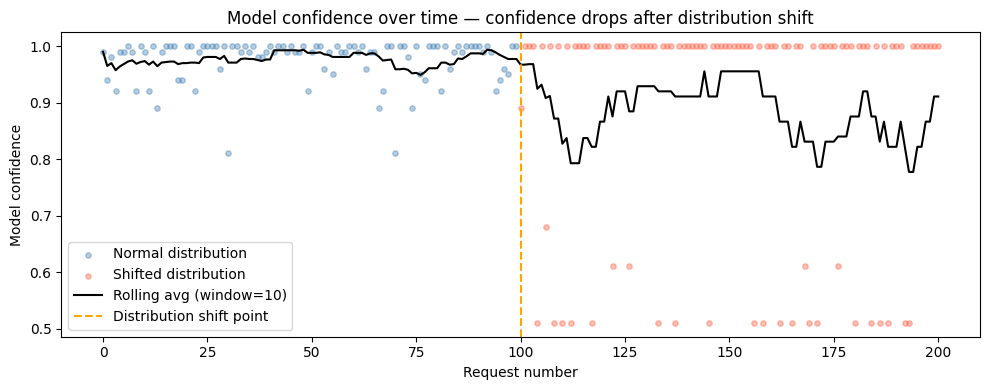

Mean confidence (normal distribution)  : 0.977
Mean confidence (shifted distribution) : 0.883
Drop in confidence: 0.093


In [4]:
# WHAT: plot per-request model confidence with a rolling average, before/after shift.
# WHY: confidence needs no ground-truth labels, so it is often the FIRST signal you
# can watch in production — labels to compute true accuracy may arrive weeks later.
import matplotlib.pyplot as plt

confidences = [r["confidence"] for r in log_records]
indices = list(range(len(confidences)))

# Rolling average (window = 10)
# Rolling mean smooths single-request noise so the trend is visible.
window = 10
rolling_avg = [
    float(np.mean(confidences[max(0, i - window): i + 1]))
    for i in indices
]

# Blue = normal traffic, red = shifted traffic, dashed line = the moment of shift.
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(indices[:100], confidences[:100], alpha=0.4, color="steelblue", label="Normal distribution", s=15)
ax.scatter(indices[100:], confidences[100:], alpha=0.4, color="tomato", label="Shifted distribution", s=15)
ax.plot(indices, rolling_avg, color="black", linewidth=1.5, label=f"Rolling avg (window={window})")
ax.axvline(x=100, color="orange", linestyle="--", linewidth=1.5, label="Distribution shift point")
ax.set_xlabel("Request number")
ax.set_ylabel("Model confidence")
ax.set_title("Model confidence over time — confidence drops after distribution shift")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/confidence_over_time.png", dpi=90)
plt.show()

# Quantify the drop the plot shows — this number could feed an alert rule.
mean_normal = float(np.mean(confidences[:100]))
mean_shifted = float(np.mean(confidences[100:]))
print(f"Mean confidence (normal distribution)  : {mean_normal:.3f}")
print(f"Mean confidence (shifted distribution) : {mean_shifted:.3f}")
print(f"Drop in confidence: {mean_normal - mean_shifted:.3f}")

## 5  Simple drift detection — compare recent inputs to training baseline

For each feature, we compare the mean of recent requests to the training mean. If the difference exceeds 2 standard deviations (of the training distribution), we flag it as drift.


In [5]:
# WHAT: statistical drift check — compare recent feature means to the training
# baseline, in units of training standard deviations.
# WHY: confidence can stay high while inputs quietly leave the training range;
# checking the INPUT distribution catches drift even before quality drops.
FEATURE_NAMES = list(iris.feature_names)
DRIFT_THRESHOLD_STD = 2.0  # flag if recent mean deviates by more than 2 training std

def detect_drift(records, train_mean, train_std, threshold_std=2.0):
    """
    Compare the mean of recent records' features to the training distribution.
    Returns a dict with per-feature drift flags.
    """
    recent_features = np.array([r["features"] for r in records])
    recent_mean = recent_features.mean(axis=0)

    deviations = np.abs(recent_mean - train_mean) / (train_std + 1e-8)
    drifted = deviations > threshold_std

    result = {
        "any_drift": bool(np.any(drifted)),
        "features": {}
    }
    for i, fname in enumerate(FEATURE_NAMES):
        result["features"][fname] = {
            "train_mean": round(float(train_mean[i]), 4),
            "recent_mean": round(float(recent_mean[i]), 4),
            "deviation_std": round(float(deviations[i]), 3),
            "drifted": bool(drifted[i])
        }
    return result


# Check normal window (requests 0-99)
drift_normal = detect_drift(log_records[:100], TRAIN_MEAN, TRAIN_STD, DRIFT_THRESHOLD_STD)
print("Drift check on normal window (requests 0-99):")
print(f"  Any drift detected: {drift_normal['any_drift']}")

# Check shifted window (requests 100-199)
drift_shifted = detect_drift(log_records[100:], TRAIN_MEAN, TRAIN_STD, DRIFT_THRESHOLD_STD)
print("\nDrift check on shifted window (requests 100-199):")
print(f"  Any drift detected: {drift_shifted['any_drift']}")
print("  Per-feature breakdown:")
for fname, info in drift_shifted["features"].items():
    flag = "DRIFT" if info["drifted"] else "ok"
    print(f"    {fname:<25} train_mean={info['train_mean']:.3f}  "
          f"recent_mean={info['recent_mean']:.3f}  "
          f"deviation={info['deviation_std']:.1f}x std  [{flag}]")

Drift check on normal window (requests 0-99):
  Any drift detected: False

Drift check on shifted window (requests 100-199):
  Any drift detected: True
  Per-feature breakdown:
    sepal length (cm)         train_mean=5.809  recent_mean=12.103  deviation=7.7x std  [DRIFT]
    sepal width (cm)          train_mean=3.062  recent_mean=5.855  deviation=6.2x std  [DRIFT]
    petal length (cm)         train_mean=3.727  recent_mean=8.426  deviation=2.7x std  [DRIFT]
    petal width (cm)          train_mean=1.183  recent_mean=2.711  deviation=2.0x std  [DRIFT]


### 5.1  Walking the detector over the log, window by window

`detect_drift()` above was handed two windows we had already chosen — one we knew was clean, one we knew was shifted. A real monitor does not get told where the shift is. It runs on a schedule, sees a window of recent traffic, and answers "quiet" or "alarm" with no idea what is coming.

So run it that way: a **30-request window, stepped 10 requests at a time**, from the start of the log to the end. Each step is one frame of the storyboard below, and the question the storyboard answers is the one an on-call engineer actually asks — *how long after the shift does the alarm fire?*

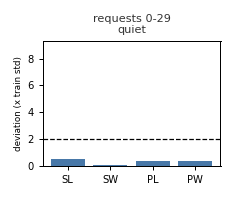

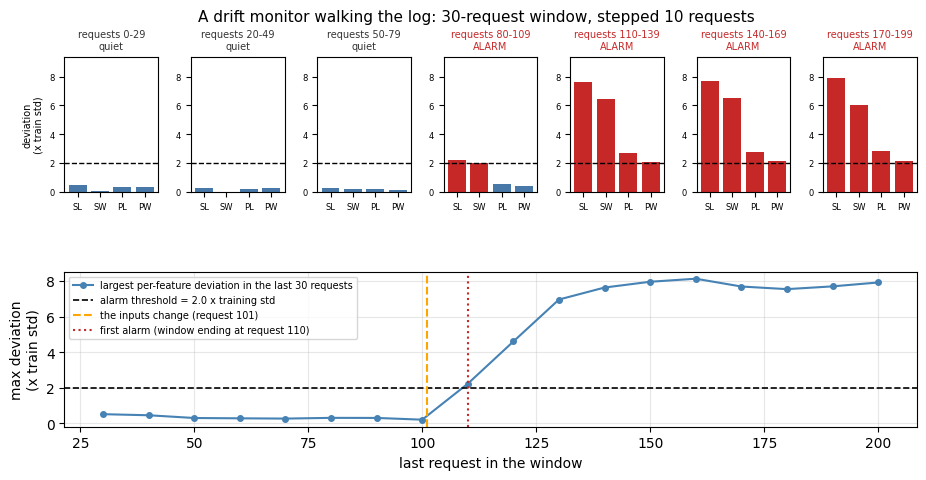

window      requests   max deviation  verdict
     0          0-29         0.51 x std  quiet
     1         10-39         0.45 x std  quiet
     2         20-49         0.29 x std  quiet
     3         30-59         0.28 x std  quiet
     4         40-69         0.26 x std  quiet
     5         50-79         0.30 x std  quiet
     6         60-89         0.30 x std  quiet
     7         70-99         0.20 x std  quiet
     8        80-109         2.22 x std  ALARM
     9        90-119         4.60 x std  ALARM
    10       100-129         6.96 x std  ALARM
    11       110-139         7.64 x std  ALARM
    12       120-149         7.96 x std  ALARM
    13       130-159         8.13 x std  ALARM
    14       140-169         7.69 x std  ALARM
    15       150-179         7.55 x std  ALARM
    16       160-189         7.70 x std  ALARM
    17       170-199         7.92 x std  ALARM

The inputs changed at request 101. The first alarm came from the window ending at request 110
-> 9 shifted 

In [6]:
# WHAT: slide detect_drift() across the whole log, capture each window as a frame,
# and show the frames as an animation (Course 09's GIF idiom) plus a static
# storyboard and a step table.
# WHY: monitoring is a process in time, not a single verdict. Watching the bars
# cross the threshold - and counting how many requests that took - is the part of
# monitoring you cannot get from one printed dict.
import io

import matplotlib.pyplot as plt

WINDOW, STEP = 30, 10
SHIFT_AT = len(log_records) - 100          # index of the first doubled request in the log

starts = list(range(0, len(log_records) - WINDOW + 1, STEP))
window_dev, window_alarm = [], []
for s in starts:
    d = detect_drift(log_records[s:s + WINDOW], TRAIN_MEAN, TRAIN_STD, DRIFT_THRESHOLD_STD)
    window_dev.append([d["features"][f]["deviation_std"] for f in FEATURE_NAMES])
    window_alarm.append(d["any_drift"])
window_dev = np.array(window_dev)
ends = [s + WINDOW for s in starts]
max_dev = window_dev.max(axis=1)
first_alarm = next((i for i, a in enumerate(window_alarm) if a), None)

# Eight frames, evenly spaced, but the first alarming window is always one of them.
picks = sorted(set(np.linspace(0, len(starts) - 1, 7).astype(int).tolist()
                   + ([first_alarm] if first_alarm is not None else [])))
short = ["".join(w[0] for w in f.split()[:2]).upper() for f in FEATURE_NAMES]
y_top = max(float(window_dev.max()) * 1.15, DRIFT_THRESHOLD_STD * 1.5)

def draw_window(ax, idx, small=False):
    """One frame: per-feature deviation bars for window `idx`, against the threshold."""
    colors = ["#c62828" if v > DRIFT_THRESHOLD_STD else "#4878a8" for v in window_dev[idx]]
    ax.bar(range(len(short)), window_dev[idx], color=colors)
    ax.axhline(DRIFT_THRESHOLD_STD, color="black", ls="--", lw=1.0)
    ax.set_ylim(0, y_top)
    ax.set_xticks(range(len(short)))
    ax.set_xticklabels(short, fontsize=6 if small else 8)
    ax.tick_params(axis="y", labelsize=6 if small else 8)
    ax.set_title(f"requests {starts[idx]}-{ends[idx] - 1}\n{'ALARM' if window_alarm[idx] else 'quiet'}",
                 fontsize=7 if small else 9,
                 color="#c62828" if window_alarm[idx] else "#333333")

# --- the animation: one small figure per frame -> one GIF (same idiom as Course 09) ---
frames = []
for idx in picks:
    f, a = plt.subplots(figsize=(2.6, 2.2), dpi=90)
    draw_window(a, idx)
    a.set_ylabel("deviation (x train std)", fontsize=7)
    f.tight_layout()
    f.canvas.draw()
    frames.append(np.asarray(f.canvas.buffer_rgba())[..., :3].copy())
    plt.close(f)

try:
    from IPython.display import Image, display
    from PIL import Image as PILImage
    imgs = [PILImage.fromarray(fr) for fr in frames]
    buf = io.BytesIO()
    imgs[0].save(buf, format="GIF", save_all=True, append_images=imgs[1:],
                 duration=700, loop=0)
    display(Image(data=buf.getvalue(), format="gif"))
except Exception as exc:                      # Pillow missing: the storyboard below still tells the story
    print(f"(animation skipped: {exc})")

# --- the storyboard: the same frames side by side, plus the whole timeline ---
fig = plt.figure(figsize=(11, 4.8))
gs = fig.add_gridspec(2, len(picks), height_ratios=[1.0, 1.15], hspace=0.55, wspace=0.35)
for k, idx in enumerate(picks):
    ax = fig.add_subplot(gs[0, k])
    draw_window(ax, idx, small=True)
    if k == 0:
        ax.set_ylabel("deviation\n(x train std)", fontsize=7)

ax = fig.add_subplot(gs[1, :])
ax.plot(ends, max_dev, marker="o", ms=4, color="steelblue",
        label=f"largest per-feature deviation in the last {WINDOW} requests")
ax.axhline(DRIFT_THRESHOLD_STD, color="black", ls="--", lw=1.2,
           label=f"alarm threshold = {DRIFT_THRESHOLD_STD} x training std")
ax.axvline(SHIFT_AT, color="orange", ls="--", lw=1.5,
           label=f"the inputs change (request {SHIFT_AT})")
if first_alarm is not None:
    ax.axvline(ends[first_alarm], color="#c62828", ls=":", lw=1.5,
               label=f"first alarm (window ending at request {ends[first_alarm]})")
ax.set_xlabel("last request in the window")
ax.set_ylabel("max deviation\n(x train std)")
ax.legend(fontsize=7, loc="upper left")
ax.grid(alpha=0.3)
fig.suptitle(f"A drift monitor walking the log: {WINDOW}-request window, stepped {STEP} requests",
             fontsize=11)
plt.show()

print(f"{'window':>6}  {'requests':>12}  {'max deviation':>14}  verdict")
for i, (s, e) in enumerate(zip(starts, ends)):
    print(f"{i:>6}  {f'{s}-{e - 1}':>12}  {max_dev[i]:>11.2f} x std  "
          f"{'ALARM' if window_alarm[i] else 'quiet'}")
if first_alarm is not None:
    print(f"\nThe inputs changed at request {SHIFT_AT}. The first alarm came from the window "
          f"ending at request {ends[first_alarm]}")
    print(f"-> {ends[first_alarm] - SHIFT_AT} shifted requests were served, and answered, before "
          f"anything fired.")

**Read the storyboard.** Left to right, each frame is the same detector run on a later slice of the log. `SL`, `SW`, `PL`, `PW` are the four iris measurements, and the bar height is how far that feature's window mean has moved from its training mean, counted in training standard deviations. While traffic looks like training data, all four bars sit flat near zero, far under the dashed threshold, and the frame is headed *quiet*.

Then watch the order in which they rise. Sepal length and sepal width cross first; petal width barely clears the line even in a window made entirely of shifted traffic. Every feature was doubled by exactly the same factor, so this ordering is not about the data changing more in some columns — it is the detector's unit. A feature whose training spread was narrow needs a smaller absolute move to count as two standard deviations. Doubling a narrow column is a scandal; doubling a wide one is barely news. That choice of unit is a design decision you inherited from `detect_drift()`, and it is why the alarm names some features and not others.

**The number to take away is the distance between the two vertical lines below.** The orange line is where the inputs actually changed; the red dotted line is where the monitor first said so; the printout states the gap in requests. It is not zero, and it cannot be: a 30-request window has to fill with enough shifted traffic to drag its mean past the threshold. Until it does, the service keeps answering — confidently — on inputs it was never trained for, and every one of those requests reached a user.

That gap is a knob, not a fact. Shorten the window and the alarm comes sooner and false-alarms more often; lengthen it and the reverse. The step table under the figure is the honest record of the setting used here (`WINDOW = 30`, `STEP = 10`) — exactly the window dilemma the "⚠️ Where this breaks" section refuses to paper over. When you report a detection latency, report the window that produced it.

## 6  Retraining trigger

Once drift is detected (or confidence drops below a threshold), you need a rule to decide whether to retrain. Here we implement a simple decision function.


In [7]:
# WHAT: a retraining trigger that fires on either low confidence or feature drift.
# WHY: monitoring is only useful if it drives action — this function is the bridge
# from 'we detected a problem' to 'the retraining pipeline starts'.
def should_retrain(records, train_mean, train_std, min_confidence=0.80, drift_threshold_std=2.0):
    """
    Returns True and a reason if retraining should be triggered.
    Two signals checked: (1) average confidence dropped, (2) feature drift detected.
    """
    if not records:
        return False, "No records to evaluate"

    # Signal 1: confidence degradation
    avg_conf = float(np.mean([r["confidence"] for r in records]))
    if avg_conf < min_confidence:
        return True, f"Average confidence {avg_conf:.3f} below threshold {min_confidence}"

    # Signal 2: feature drift
    drift = detect_drift(records, train_mean, train_std, drift_threshold_std)
    if drift["any_drift"]:
        drifted_features = [
            f for f, info in drift["features"].items() if info["drifted"]
        ]
        return True, f"Drift detected in features: {drifted_features}"

    return False, "No retraining needed"


# Evaluate on the normal window
retrain, reason = should_retrain(log_records[:100], TRAIN_MEAN, TRAIN_STD)
print(f"Normal window  -> Retrain: {retrain}  |  Reason: {reason}")

# Evaluate on the shifted window
retrain, reason = should_retrain(log_records[100:], TRAIN_MEAN, TRAIN_STD)
print(f"Shifted window -> Retrain: {retrain}  |  Reason: {reason}")

# Evaluate on the full log
retrain, reason = should_retrain(log_records, TRAIN_MEAN, TRAIN_STD)
print(f"Full log       -> Retrain: {retrain}  |  Reason: {reason}")

Normal window  -> Retrain: False  |  Reason: No retraining needed
Shifted window -> Retrain: True  |  Reason: Drift detected in features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Full log       -> Retrain: True  |  Reason: Drift detected in features: ['sepal length (cm)', 'sepal width (cm)']


### 6.1  The drift neither monitor can see

Everything so far detected **data drift**: the inputs changed, so the input monitor moved. `should_retrain()` now watches two signals, and both of them are computed from things a live service already has — the feature values it receives and the confidence it emits.

Zillow's failure was not of that kind. Houses kept arriving with ordinary square footage, ordinary bedroom counts, ordinary postcodes. What changed was the *price those features imply* — the relationship between input and answer, not the inputs. That is **concept drift**, and the question this section settles is whether the monitoring we just built would have noticed.

Simulate it in the only way concept drift can be simulated: hold the input distribution completely fixed, and change the labelling rule halfway through. Requests keep coming from the same held-out iris rows; from request 101 the ground truth for *versicolor* and *virginica* is swapped, as if a revision to the classification scheme had taken effect that morning. The flowers did not change. The right answer did.

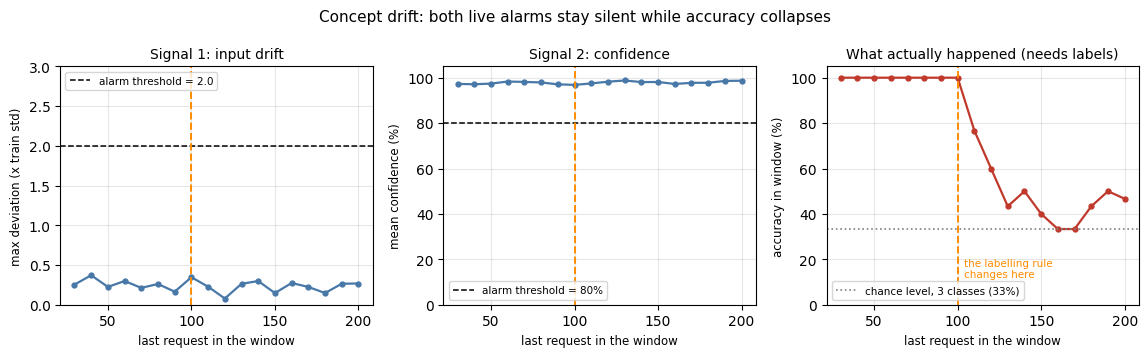

window                        before the change   after the change
max input deviation                       0.27x              0.24x
mean confidence                          97.5%             98.1%
accuracy                                100.0%             42.5%

should_retrain() on the 100 post-change requests -> False
  reason: No retraining needed


In [8]:
# WHAT: 200 requests whose INPUTS never change distribution, but whose ground-truth
# labels change at request 101. Run all three signals over the same sliding window
# used in section 5.1 and plot them side by side.
# WHY: data drift and concept drift are not two flavours of the same problem. One
# is visible in the request stream; the other is only visible once labels arrive.
import matplotlib.pyplot as plt

CONCEPT_SHIFT_AT = 100                    # request index where the labelling rule changes
RELABEL = {0: 0, 1: 2, 2: 1}              # versicolor <-> virginica; setosa untouched

rng = np.random.default_rng(7)            # local generator: leaves the section 3 seed alone
concept_records = []
for i in range(2 * CONCEPT_SHIFT_AT):
    idx = int(rng.integers(0, len(X_test)))
    x = X_test[idx]                       # REAL held-out row, same distribution throughout
    proba = model.predict_proba([x])[0]
    pred = int(proba.argmax())
    truth = int(y_test[idx]) if i < CONCEPT_SHIFT_AT else RELABEL[int(y_test[idx])]
    concept_records.append({
        "features": [float(v) for v in x],
        "prediction": pred,
        "confidence": float(proba[pred]),
        "truth": truth,                   # arrives weeks later in real life
    })

# Same window and step as the storyboard in 5.1, so the two are comparable.
starts = list(range(0, len(concept_records) - WINDOW + 1, STEP))
ends, max_dev_c, mean_conf_c, window_acc = [], [], [], []
for s in starts:
    w = concept_records[s:s + WINDOW]
    d = detect_drift(w, TRAIN_MEAN, TRAIN_STD, DRIFT_THRESHOLD_STD)
    max_dev_c.append(max(v["deviation_std"] for v in d["features"].values()))
    mean_conf_c.append(float(np.mean([r["confidence"] for r in w])))
    window_acc.append(float(np.mean([r["prediction"] == r["truth"] for r in w])))
    ends.append(s + WINDOW)

fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.6), sharex=True)

ax = axes[0]
ax.plot(ends, max_dev_c, marker="o", ms=3.5, color="#4878a8", lw=1.6)
ax.axhline(DRIFT_THRESHOLD_STD, color="black", ls="--", lw=1.1,
           label=f"alarm threshold = {DRIFT_THRESHOLD_STD}")
ax.set_ylim(0, DRIFT_THRESHOLD_STD * 1.5)
ax.set_ylabel("max deviation (x train std)", fontsize=8.5)
ax.set_title("Signal 1: input drift", fontsize=10)
ax.legend(fontsize=7.5, loc="upper left")

ax = axes[1]
ax.plot(ends, [c * 100 for c in mean_conf_c], marker="o", ms=3.5, color="#4878a8", lw=1.6)
ax.axhline(80, color="black", ls="--", lw=1.1, label="alarm threshold = 80%")
ax.set_ylim(0, 105)
ax.set_ylabel("mean confidence (%)", fontsize=8.5)
ax.set_title("Signal 2: confidence", fontsize=10)
ax.legend(fontsize=7.5, loc="lower left")

ax = axes[2]
ax.plot(ends, [a * 100 for a in window_acc], marker="o", ms=3.5, color="#c0392b", lw=1.6)
ax.axhline(100 / 3, color="grey", ls=":", lw=1.2, label="chance level, 3 classes (33%)")
ax.set_ylim(0, 105)
ax.set_ylabel("accuracy in window (%)", fontsize=8.5)
ax.set_title("What actually happened (needs labels)", fontsize=10)
ax.legend(fontsize=7.5, loc="lower left")

for ax in axes:
    ax.axvline(CONCEPT_SHIFT_AT, color="darkorange", ls="--", lw=1.4)
    ax.set_xlabel("last request in the window", fontsize=8.5)
    ax.grid(alpha=0.3)
axes[2].text(CONCEPT_SHIFT_AT + 4, 12, "the labelling rule\nchanges here",
             fontsize=7.5, color="darkorange")

fig.suptitle("Concept drift: both live alarms stay silent while accuracy collapses", fontsize=11)
plt.tight_layout()
plt.show()

before = [i for i, e in enumerate(ends) if e <= CONCEPT_SHIFT_AT]
after = [i for i, e in enumerate(ends) if e >= CONCEPT_SHIFT_AT + WINDOW]
fire, reason = should_retrain(concept_records[CONCEPT_SHIFT_AT:], TRAIN_MEAN, TRAIN_STD)
print(f"{'window':28s} {'before the change':>18s} {'after the change':>18s}")
print(f"{'max input deviation':28s} "
      f"{np.mean([max_dev_c[i] for i in before]):17.2f}x {np.mean([max_dev_c[i] for i in after]):17.2f}x")
print(f"{'mean confidence':28s} "
      f"{np.mean([mean_conf_c[i] for i in before]):17.1%} {np.mean([mean_conf_c[i] for i in after]):17.1%}")
print(f"{'accuracy':28s} "
      f"{np.mean([window_acc[i] for i in before]):17.1%} {np.mean([window_acc[i] for i in after]):17.1%}")
print(f"\nshould_retrain() on the 100 post-change requests -> {fire}")
print(f"  reason: {reason}")

**Read the figure.** Three panels, one shared x-axis, and the orange dashed line in all three marks the request where the labelling rule changed.

- **Left — input drift.** The blue trace wanders between roughly 0.1 and 0.4 training standard deviations for the whole run and never approaches the dashed alarm line at 2.0. It should not: the requests before and after the change are drawn from the same held-out rows. There is nothing here to detect.
- **Middle — confidence.** Flat, high, and above the 80% alarm line from the first window to the last. The forest is exactly as sure of itself after the change as before, because nothing about the inputs told it anything had happened.
- **Right — accuracy.** It sits at 100% until the orange line, then drops within three windows to the neighbourhood of the grey dotted chance line for three classes, bouncing between roughly a third and a half for the rest of the run. The model is now wrong on two of the three species and the printed table gives the before/after numbers.

Then read the last printed line: **`should_retrain()` returns `False`.** Our trigger, applied to the hundred requests after the change, sees a quiet input distribution and a confident model and correctly reports that neither of its two signals fired. The function is not broken. It is measuring the only two things a live service can measure, and neither of them contains the information.

This is the shape of the Zillow failure at the top of the notebook, and it is why the ⚠️ section below insists that input drift and concept drift are different problems. The only signal in this figure that moved is the one that requires **ground truth** — labels that in a real deployment arrive days, weeks or (for a house that has to be resold) months late. Three practical consequences:

1. **Build the label pipeline, not just the log.** A monitoring system with no path for delayed ground truth can only ever detect the easy half of drift.
2. **Where labels are slow, buy a proxy.** Manually label a small sample of recent traffic every week, or watch a downstream business metric that correlates with correctness.
3. **Consider retraining on a schedule anyway.** The 2026 window-dilemma paper cited below reports that plain scheduled retraining often beats drift-triggered retraining — and a figure like this one is why: a trigger can only fire on what it can see.

## 💬 Discuss

Three printed numbers should bother you. Doubling **every** feature moved mean confidence only from **0.977 to 0.883** — the model stayed 88% sure on inputs it had never seen. The drift check on the shifted window flagged all four features. And the drift check on the **full log** flagged only two, because mixing 100 normal requests with 100 shifted ones halved the apparent shift.

1. If confidence barely moves when the inputs double, how much weight should confidence carry as a production alarm? Name a situation where confidence would be the *only* signal you have, and say what you would do with it there.
2. The verdict changed with the window. Same data, same detector, different answer — "drift in 4 features" or "drift in 2" depending on where you cut. How would you choose a window length, and what would you tell a colleague who tuned the window until the alert stopped firing?
3. `should_retrain()` fires on drift. Zillow's problem was not that inputs looked strange — house features looked normal — it was that the *relationship* between them and price had changed. Design a trigger that would have caught that, and then say honestly what it needs that this notebook does not have.

## Summary

The monitoring loop for a deployed model has four stages:

| Stage | What happens |
|---|---|
| Log | Every request writes timestamp, features, prediction, confidence to a log file |
| Analyze | Periodically compute rolling averages and compare feature means to training baseline |
| Alert | If confidence drops or drift exceeds threshold, flag for human review |
| Retrain | Collect new labeled data, retrain, validate, deploy — then the cycle restarts |

Data drift usually *does* show up as a confidence drop — the model sees inputs unlike anything in its training data. Concept drift is the dangerous one: the inputs can look completely normal (so confidence stays high) while the correct answer has changed underneath you. That is why concept drift generally cannot be caught by watching inputs or confidence alone — you need fresh labels to measure accuracy directly.


## Self-check

1. **What is the difference between data drift and concept drift?** Look at the Section 1 definitions and think of one real-world example of each from an industry you know.
2. **How would you know your model's accuracy has dropped if you don't have labels for new data?** Confidence is a proxy — but what are its limitations? When would high confidence still mean wrong predictions?
3. **Name two signals that should trigger a retraining pipeline.** Look at `should_retrain()` in Section 6 — what are the two signals it checks? Can you think of a third that would be more reliable than either?


## ⚠️ Where this breaks

This is a real monitoring loop, and it has four holes you should be able to name before you rely on it.

- **Confidence is a weak drift detector, and this notebook proves it.** Every feature was doubled and mean confidence fell by 0.09. A softmax or a forest vote share is not a calibrated probability; models are routinely confident far outside their training range. Treat a confidence drop as evidence *something* changed, never as evidence that nothing did.
- **The window defines the verdict.** Our own output flips from four drifted features to two purely by widening the window. A 2026 analysis (*The Window Dilemma: Why Concept Drift Detection is Ill-Posed*, arXiv 2602.06456) argues this is not a tuning problem but a structural one, and reports that plain **scheduled retraining** often outperforms drift-aware methods. If your detector's answer depends on a knob you chose, say so out loud when you report it.
- **Input drift ≠ concept drift, and only one of them is visible here.** Everything we measure looks at `P(X)`. Zillow's failure was in `P(Y|X)`: the same house features stopped implying the same price. No amount of input monitoring catches that. **You need fresh labels**, and if labels arrive weeks late, your detection latency is weeks — plan the business response around that number, not around the alert.
- **The assumption that must hold:** the training baseline (`train_mean`, `train_std`) describes the model actually in production. Retrain and redeploy without recomputing the baseline and the monitor is comparing live traffic against a model that no longer exists — it will either alarm constantly or never.
- **The cheaper alternative.** For a low-stakes model with a stable input pipeline, a monthly cron job that recomputes accuracy on freshly labelled data and emails the result beats a real-time drift detector that nobody has calibrated. Detection machinery costs engineering time and produces false alarms; buy it only when the cost of finding out late is genuinely high.

**The same reasoning shows up elsewhere:** a credit scorecard whose population shifts after an interest-rate change; a demand forecast trained before a supply-chain disruption; a speech model deployed to a new dialect region. In each, the code is fine and the world moved.

## 📚 References

1. Breck, E., Cai, S., Nielsen, E., Salib, M., & Sculley, D. (2017). *The ML Test Score: A Rubric for ML Production Readiness and Technical Debt Reduction*. IEEE Big Data. <https://research.google/pubs/the-ml-test-score-a-rubric-for-ml-production-readiness-and-technical-debt-reduction/>
2. Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M., & Bouchachia, A. (2014). *A Survey on Concept Drift Adaptation*. ACM Computing Surveys 46(4).
3. Klaise, J., Van Looveren, A., Cox, C., Vacanti, G., & Coca, A. (2020). *Monitoring and Explainability of Models in Production*. ICML Workshop on Challenges in Deploying and Monitoring ML Systems. <https://arxiv.org/abs/2007.06299>
